# Support Vector Machine (SVM) - Machine Learning Practical
### Linear SVM, Non-Linear SVM, and SVM with Different Kernels

**Name:** _(your name here)_
**Roll No:** _(your roll no here)_
**Subject:** Machine Learning

In this practical we implement and compare different types of SVM models -
Linear SVM without kernel, Linear SVM with Linear Kernel, and Non-Linear SVM using
Gaussian, RBF, Sigmoid and Polynomial kernels.

This version uses the **Breast Cancer Wisconsin dataset** (real-world, for the
linear experiments) and the **Moons dataset** (synthetic, for the non-linear
experiments), instead of the blobs/circles datasets used previously.


## What is SVM?

A **Support Vector Machine (SVM)** is a supervised learning algorithm used for
classification. SVM works by finding an **optimal separating hyperplane** that
divides the data points of different classes.

- **Decision Boundary:** The line (or curve) that separates the two classes.
- **Margin:** The distance between the decision boundary and the closest data
  points of each class. SVM tries to **maximize the margin** between the classes.
- **Support Vectors:** The data points that are closest to the decision boundary.
  These points "support" or decide the position of the margin, hence the name
  Support Vector Machine.

If the data is not perfectly separable, SVM allows some points to violate the
margin using **slack variables**, controlled by a penalty parameter `C`. This is
called a **Soft Margin SVM**, as opposed to a **Hard Margin SVM** where no
violations are allowed at all.

When data cannot be separated using a straight line, SVM can map the data into a
higher-dimensional space using a **kernel**, where a straight-line separation
becomes possible. This is known as the **kernel trick**.


## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score

## 2. A Simple Function to Plot the Decision Boundary

Since we will be plotting the decision boundary many times in this notebook, we
write one simple function for it and reuse it everywhere.


In [2]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

---
# Experiment 1 : Linear and Non-Linear SVM without Kernel
---

## 1A. Linear SVM without Kernel

First we create a 2D dataset that is (approximately) **linearly separable**,
using two features from the **Breast Cancer Wisconsin dataset**: `mean radius`
and `mean texture`. The two classes are malignant and benign tumours. We use
`LinearSVC`, which solves the SVM optimization directly (without using the
kernel trick).


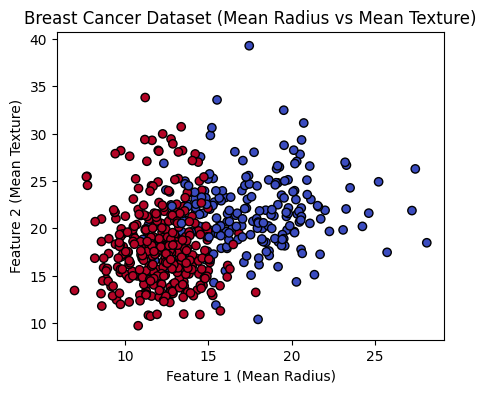

In [3]:
cancer = load_breast_cancer()
X_linear = cancer.data[:, [0, 1]]   # mean radius, mean texture
y_linear = cancer.target             # 0 = malignant, 1 = benign

plt.figure(figsize=(5, 4))
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, cmap='coolwarm', edgecolors='k')
plt.title("Breast Cancer Dataset (Mean Radius vs Mean Texture)")
plt.xlabel("Feature 1 (Mean Radius)")
plt.ylabel("Feature 2 (Mean Texture)")
plt.show()

In [4]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)

print("Training samples:", X_train_lin.shape[0])
print("Testing samples :", X_test_lin.shape[0])

Training samples: 455
Testing samples : 114


In [5]:
model_1a = LinearSVC(max_iter=10000)
model_1a.fit(X_train_lin, y_train_lin)

train_pred_1a = model_1a.predict(X_train_lin)
test_pred_1a = model_1a.predict(X_test_lin)

train_acc_1a = accuracy_score(y_train_lin, train_pred_1a)
test_acc_1a = accuracy_score(y_test_lin, test_pred_1a)

print("Training Accuracy:", train_acc_1a)
print("Testing Accuracy :", test_acc_1a)

Training Accuracy: 0.8791208791208791
Testing Accuracy : 0.8947368421052632


`LinearSVC` does not directly give us the support vectors like `SVC` does. So to
identify the points that are close to the decision boundary (i.e. behave like
support vectors), we calculate the decision function value for every training
point. Points with a value between -1 and 1 lie inside or on the margin, so we
treat them as approximate support vectors.


In [6]:
decision_values = model_1a.decision_function(X_train_lin)
support_vector_mask = np.abs(decision_values) <= 1
approx_support_vectors = X_train_lin[support_vector_mask]

print("Number of approximate support vectors:", len(approx_support_vectors))
print(approx_support_vectors)

Number of approximate support vectors: 286
[[10.65  25.22 ]
 [14.54  27.54 ]
 [14.41  19.73 ]
 [12.25  17.94 ]
 [12.36  21.8  ]
 [14.87  16.67 ]
 [13.4   16.95 ]
 [17.99  10.38 ]
 [15.22  30.62 ]
 [14.26  18.17 ]
 [11.7   19.11 ]
 [15.27  12.91 ]
 [15.34  14.26 ]
 [13.51  18.89 ]
 [14.64  15.24 ]
 [14.45  20.22 ]
 [12.89  13.12 ]
 [13.4   20.52 ]
 [12.96  18.29 ]
 [15.28  22.41 ]
 [13.78  15.79 ]
 [15.1   22.02 ]
 [12.34  14.95 ]
 [13.45  18.3  ]
 [11.32  27.08 ]
 [14.86  16.94 ]
 [12.56  19.07 ]
 [15.13  29.81 ]
 [12.78  16.49 ]
 [14.74  25.42 ]
 [13.82  24.49 ]
 [12.89  14.11 ]
 [13.74  17.91 ]
 [13.37  16.39 ]
 [14.69  13.98 ]
 [12.91  16.33 ]
 [13.62  23.23 ]
 [17.35  23.06 ]
 [15.    15.51 ]
 [11.8   17.26 ]
 [14.53  13.98 ]
 [13.71  18.68 ]
 [16.11  18.05 ]
 [18.49  17.52 ]
 [13.71  20.83 ]
 [14.47  24.99 ]
 [13.54  14.36 ]
 [15.46  11.89 ]
 [12.85  21.37 ]
 [12.47  17.31 ]
 [12.46  19.89 ]
 [10.86  21.48 ]
 [11.37  18.89 ]
 [13.49  22.3  ]
 [17.14  16.4  ]
 [14.61  15.69 ]
 [13.

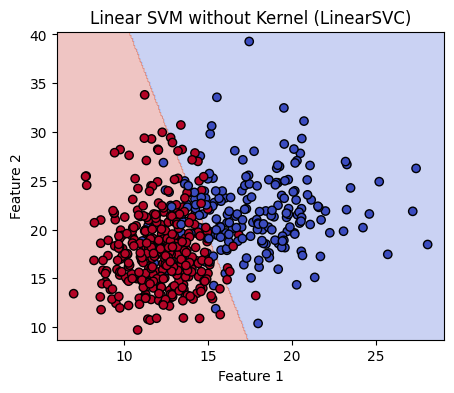

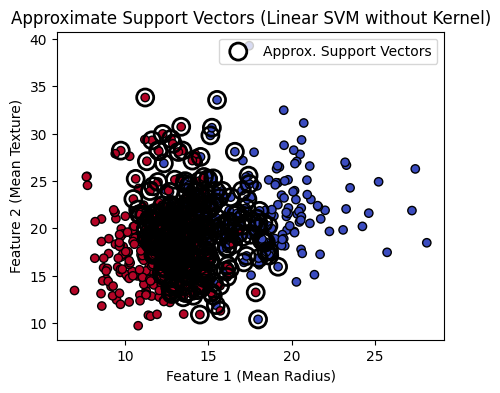

In [7]:
plot_decision_boundary(model_1a, X_linear, y_linear, "Linear SVM without Kernel (LinearSVC)")

plt.figure(figsize=(5, 4))
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, cmap='coolwarm', edgecolors='k')
plt.scatter(approx_support_vectors[:, 0], approx_support_vectors[:, 1],
            facecolors='none', edgecolors='black', s=150, linewidths=2, label='Approx. Support Vectors')
plt.title("Approximate Support Vectors (Linear SVM without Kernel)")
plt.xlabel("Feature 1 (Mean Radius)")
plt.ylabel("Feature 2 (Mean Texture)")
plt.legend()
plt.show()

**Conclusion:** The Linear SVM without kernel (`LinearSVC`) was able to separate
the two classes reasonably well with a straight-line decision boundary on the
Breast Cancer data, since malignant and benign tumours are largely separable
using just mean radius and mean texture. Training and testing accuracy were
both high.

## 1B. Non-Linear SVM without Kernel

Now let us create a dataset that is **not linearly separable** - two
interleaving half-moon shaped clusters, generated using `make_moons`. We will
try to fit the same kind of model (without a kernel) and see what happens.


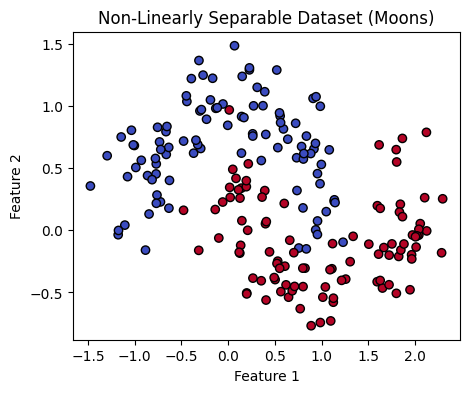

In [8]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.2, random_state=42)

plt.figure(figsize=(5, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k')
plt.title("Non-Linearly Separable Dataset (Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [9]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)

model_1b = LinearSVC(max_iter=10000)
model_1b.fit(X_train_c, y_train_c)

train_pred_1b = model_1b.predict(X_train_c)
test_pred_1b = model_1b.predict(X_test_c)

train_acc_1b = accuracy_score(y_train_c, train_pred_1b)
test_acc_1b = accuracy_score(y_test_c, test_pred_1b)

print("Training Accuracy:", train_acc_1b)
print("Testing Accuracy :", test_acc_1b)

Training Accuracy: 0.8375
Testing Accuracy : 0.825


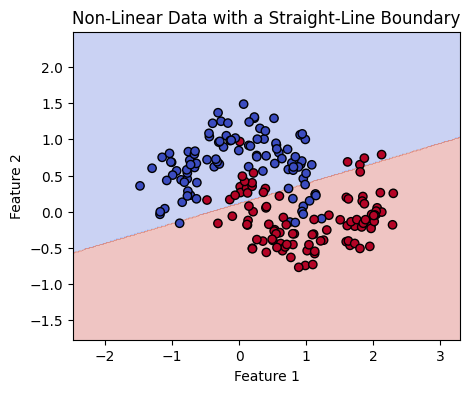

In [10]:
plot_decision_boundary(model_1b, X_moons, y_moons, "Non-Linear Data with a Straight-Line Boundary")

**Observation:** A straight line cannot properly separate the two interleaving
half-moon shaped clusters. Because of this, a noticeable number of points end
up on the wrong side of the boundary, and the accuracy is lower than in the
linear (Breast Cancer) case.

**Conclusion:** This experiment shows the difference between linear and
non-linear data. Linear data can be separated well by a straight line, but
non-linear data (like this moons pattern) needs a curved decision boundary,
which we can get by using a **kernel** (shown in the next experiments).

---
# Experiment 2 : Linear SVM with Linear Kernel
---

Now we use the same (Breast Cancer) linearly separable dataset, but this time we
use `SVC(kernel='linear')`. This uses the kernel trick internally (with a linear
kernel), and unlike `LinearSVC`, it directly gives us the actual support
vectors through the `support_vectors_` attribute.


In [11]:
model_2 = SVC(kernel='linear')
model_2.fit(X_train_lin, y_train_lin)

train_pred_2 = model_2.predict(X_train_lin)
test_pred_2 = model_2.predict(X_test_lin)

train_acc_2 = accuracy_score(y_train_lin, train_pred_2)
test_acc_2 = accuracy_score(y_test_lin, test_pred_2)

print("Training Accuracy:", train_acc_2)
print("Testing Accuracy :", test_acc_2)

Training Accuracy: 0.8879120879120879
Testing Accuracy : 0.9035087719298246


In [12]:
support_vectors_2 = X_train_lin[model_2.support_]

print("Number of Support Vectors:", len(support_vectors_2))
print("Support Vectors:")
print(support_vectors_2)

Number of Support Vectors: 129
Support Vectors:
[[14.54 27.54]
 [14.87 16.67]
 [17.99 10.38]
 [15.34 14.26]
 [14.45 20.22]
 [13.4  20.52]
 [15.28 22.41]
 [15.1  22.02]
 [13.82 24.49]
 [16.11 18.05]
 [13.71 20.83]
 [15.46 11.89]
 [13.61 24.69]
 [11.84 18.7 ]
 [14.71 21.59]
 [16.13 20.68]
 [14.27 22.55]
 [15.06 19.83]
 [12.45 15.7 ]
 [15.61 19.38]
 [14.68 20.13]
 [11.42 20.38]
 [14.58 21.53]
 [12.83 22.33]
 [14.86 23.21]
 [12.34 26.86]
 [14.25 21.72]
 [11.76 18.14]
 [14.99 25.2 ]
 [11.8  16.58]
 [15.75 20.25]
 [15.05 19.07]
 [13.17 21.81]
 [14.78 23.94]
 [16.24 18.77]
 [15.75 19.22]
 [16.25 19.51]
 [10.95 21.35]
 [15.49 19.97]
 [14.9  22.53]
 [13.61 24.98]
 [13.43 19.63]
 [13.86 16.93]
 [13.17 18.66]
 [15.5  21.08]
 [14.95 17.57]
 [14.25 22.15]
 [12.77 22.47]
 [13.   21.82]
 [12.68 23.84]
 [13.73 22.61]
 [13.44 21.58]
 [11.08 18.83]
 [13.28 20.28]
 [14.22 23.12]
 [13.11 15.56]
 [15.12 16.68]
 [16.13 17.88]
 [15.37 22.76]
 [14.6  23.29]
 [14.42 19.77]
 [16.03 15.51]
 [14.19 23.81]
 [13.98

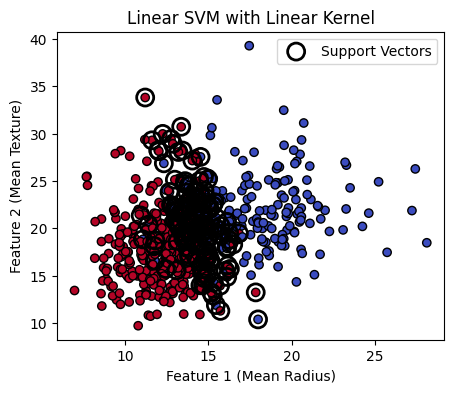

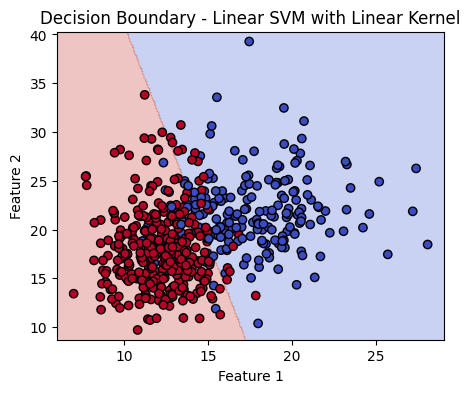

In [13]:
plt.figure(figsize=(5, 4))
plt.scatter(X_linear[:, 0], X_linear[:, 1], c=y_linear, cmap='coolwarm', edgecolors='k')
plt.scatter(support_vectors_2[:, 0], support_vectors_2[:, 1],
            facecolors='none', edgecolors='black', s=150, linewidths=2, label='Support Vectors')
plt.title("Linear SVM with Linear Kernel")
plt.xlabel("Feature 1 (Mean Radius)")
plt.ylabel("Feature 2 (Mean Texture)")
plt.legend()
plt.show()

plot_decision_boundary(model_2, X_linear, y_linear, "Decision Boundary - Linear SVM with Linear Kernel")

**Conclusion:** The Linear SVM with Linear Kernel gives almost the same
accuracy and the same kind of straight-line decision boundary as the Linear SVM
without kernel. The main difference is that this model directly gives us the
support vectors, which are the points lying closest to the margin.

---
# Experiment 3 : Non-Linear SVM with Different Kernels
---

We will now use the moons (non-linear) dataset created earlier and apply
SVM with four different kernels: **Gaussian**, **RBF**, **Sigmoid**, and
**Polynomial**. A kernel allows SVM to create a curved (non-linear) decision
boundary by internally mapping the data into a higher-dimensional space.


## 3A. Gaussian Kernel

The Gaussian kernel measures similarity between two points using a bell-shaped
(Gaussian) function of the distance between them. Scikit-learn does not have a
kernel named `'gaussian'` directly, so we write our own simple Gaussian kernel
function and pass it to `SVC`.


In [14]:
def gaussian_kernel(X1, X2, gamma=0.5):
    pairwise_sq_dists = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * pairwise_sq_dists)

In [15]:
model_3a = SVC(kernel=gaussian_kernel)
model_3a.fit(X_train_c, y_train_c)

train_pred_3a = model_3a.predict(X_train_c)
test_pred_3a = model_3a.predict(X_test_c)

train_acc_3a = accuracy_score(y_train_c, train_pred_3a)
test_acc_3a = accuracy_score(y_test_c, test_pred_3a)

print("Training Accuracy:", train_acc_3a)
print("Testing Accuracy :", test_acc_3a)
print("Number of Support Vectors:", len(model_3a.support_))

Training Accuracy: 0.925
Testing Accuracy : 0.925
Number of Support Vectors: 58


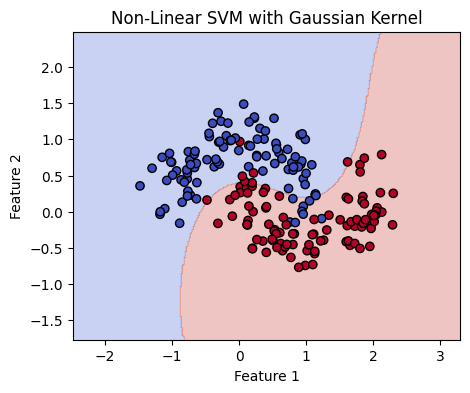

In [16]:
plot_decision_boundary(model_3a, X_moons, y_moons, "Non-Linear SVM with Gaussian Kernel")

**Conclusion:** The Gaussian kernel was able to create a curved decision
boundary that separates the two moon-shaped clusters much better than a
straight line.

## 3B. Gaussian Radial Basis Function (RBF) Kernel

The RBF kernel available in scikit-learn (`kernel='rbf'`) works on the same
Gaussian radial basis function idea as above, and is the most commonly used
kernel for non-linear data.


In [17]:
model_3b = SVC(kernel='rbf', gamma=0.5)
model_3b.fit(X_train_c, y_train_c)

train_pred_3b = model_3b.predict(X_train_c)
test_pred_3b = model_3b.predict(X_test_c)

train_acc_3b = accuracy_score(y_train_c, train_pred_3b)
test_acc_3b = accuracy_score(y_test_c, test_pred_3b)

print("Training Accuracy:", train_acc_3b)
print("Testing Accuracy :", test_acc_3b)
print("Number of Support Vectors:", len(model_3b.support_))

Training Accuracy: 0.925
Testing Accuracy : 0.925
Number of Support Vectors: 58


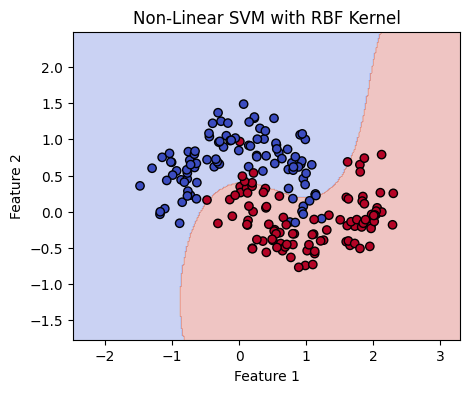

In [18]:
plot_decision_boundary(model_3b, X_moons, y_moons, "Non-Linear SVM with RBF Kernel")

**Conclusion:** The RBF kernel creates a smooth, curved, non-linear decision
boundary and gives very high accuracy on this moons dataset.

## 3C. Sigmoid Kernel

The sigmoid kernel is inspired by the activation function used in neural
networks. It sometimes behaves similar to a linear kernel and may not always
work well for every dataset.


In [19]:
model_3c = SVC(kernel='sigmoid', gamma=0.5)
model_3c.fit(X_train_c, y_train_c)

train_pred_3c = model_3c.predict(X_train_c)
test_pred_3c = model_3c.predict(X_test_c)

train_acc_3c = accuracy_score(y_train_c, train_pred_3c)
test_acc_3c = accuracy_score(y_test_c, test_pred_3c)

print("Training Accuracy:", train_acc_3c)
print("Testing Accuracy :", test_acc_3c)
print("Number of Support Vectors:", len(model_3c.support_))

Training Accuracy: 0.71875
Testing Accuracy : 0.65
Number of Support Vectors: 63


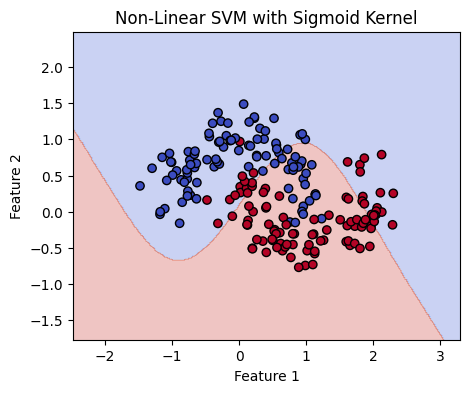

In [20]:
plot_decision_boundary(model_3c, X_moons, y_moons, "Non-Linear SVM with Sigmoid Kernel")

**Conclusion:** The Sigmoid kernel did not perform as well as the Gaussian or
RBF kernel on this moons dataset, since its shape is not well suited for this
kind of pattern.

## 3D. Polynomial Kernel

The polynomial kernel maps the data using polynomial combinations of the
original features. We use a simple degree of 3 here.


In [21]:
model_3d = SVC(kernel='poly', degree=3)
model_3d.fit(X_train_c, y_train_c)

train_pred_3d = model_3d.predict(X_train_c)
test_pred_3d = model_3d.predict(X_test_c)

train_acc_3d = accuracy_score(y_train_c, train_pred_3d)
test_acc_3d = accuracy_score(y_test_c, test_pred_3d)

print("Training Accuracy:", train_acc_3d)
print("Testing Accuracy :", test_acc_3d)
print("Number of Support Vectors:", len(model_3d.support_))

Training Accuracy: 0.90625
Testing Accuracy : 0.925
Number of Support Vectors: 68


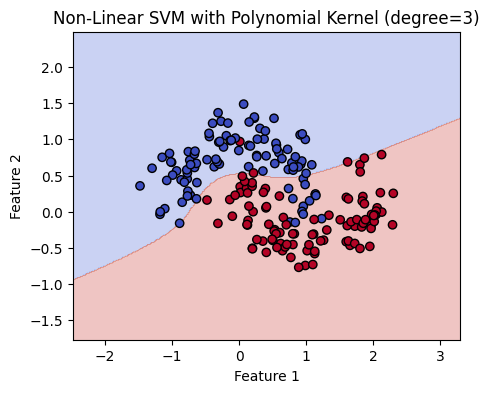

In [22]:
plot_decision_boundary(model_3d, X_moons, y_moons, "Non-Linear SVM with Polynomial Kernel (degree=3)")

**Conclusion:** The Polynomial kernel was able to curve the decision boundary
to some extent, but on this particular moons dataset it did not perform as well
as the Gaussian/RBF kernel.

---
# Comparison of All SVM Models
---

In [23]:
comparison_table = pd.DataFrame({
    'Model': ['Linear SVM', 'Linear SVM', 'Non-Linear SVM', 'Non-Linear SVM', 'Non-Linear SVM', 'Non-Linear SVM'],
    'Kernel': ['None', 'Linear', 'Gaussian', 'RBF', 'Sigmoid', 'Polynomial'],
    'Train Accuracy': [train_acc_1a, train_acc_2, train_acc_3a, train_acc_3b, train_acc_3c, train_acc_3d],
    'Test Accuracy': [test_acc_1a, test_acc_2, test_acc_3a, test_acc_3b, test_acc_3c, test_acc_3d]
})

comparison_table

,Model,Kernel,Train Accuracy,Test Accuracy
0,Linear SVM,None,0.879121,0.894737
1,Linear SVM,Linear,0.887912,0.903509
2,Non-Linear SVM,Gaussian,0.925000,0.925000
3,Non-Linear SVM,RBF,0.925000,0.925000
4,Non-Linear SVM,Sigmoid,0.718750,0.650000
5,Non-Linear SVM,Polynomial,0.906250,0.925000


In [24]:
best_row = comparison_table.loc[comparison_table['Test Accuracy'].idxmax()]
print("Best performing model on test data:")
print(best_row)

Best performing model on test data:
Model             Non-Linear SVM
Kernel                  Gaussian
Train Accuracy             0.925
Test Accuracy              0.925
Name: 2, dtype: object


**Comparison:** The Linear SVM models (with and without kernel) performed
very well on the Breast Cancer dataset, since the two classes are largely
separable using a straight line on these two features. Among the non-linear
kernels, the **Gaussian and RBF kernels** performed the best on the moons
dataset, because they can form smooth curved boundaries, while the **Sigmoid
kernel** performed the weakest for this kind of data.

---
# Overall Conclusion
---

In this practical, we learned the following:

1. **SVM** works by finding an optimal separating hyperplane that maximizes the
   margin between two classes, and the closest points to this hyperplane are
   called **support vectors**.

2. **Linear SVM without Kernel** (`LinearSVC`) works directly on linearly
   separable data (here, the Breast Cancer dataset) and does not use the
   kernel trick, so it does not directly give us the support vectors.

3. **Non-Linear SVM without Kernel** shows that a straight-line boundary fails
   badly on data that is not linearly separable, like our moons dataset.

4. **Linear SVM with Linear Kernel** (`SVC(kernel='linear')`) gives similar
   accuracy to the Linear SVM without kernel, but it directly gives us the
   actual support vectors.

5. **Non-Linear SVM with Kernels** (Gaussian, RBF, Sigmoid, Polynomial) allow
   SVM to create curved decision boundaries by mapping data into a
   higher-dimensional space. Among these, the **Gaussian/RBF kernel** worked
   best for our moons dataset, while the **Sigmoid kernel** worked the least
   well.

Overall, this practical helped us understand how the choice of kernel affects
the shape of the SVM decision boundary and the accuracy of the model, and how
important it is to choose the right kernel depending on whether the data is
linearly separable or not.
